In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [5]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [6]:
df.shape

(4269, 13)

In [7]:
df[' education'].value_counts()

 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [8]:
df[' self_employed'].value_counts()

 self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [9]:
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [10]:
df.columns = df.columns.str.strip()

In [11]:
df['education'] = df['education'].str.strip()

In [12]:
df['self_employed'] = df['self_employed'].str.strip()

In [13]:
df['loan_status'] = df['loan_status'].str.strip()

In [14]:
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [15]:
print(df['loan_status'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [16]:
df.drop(columns=['loan_id'], inplace=True)

In [17]:
df.shape

(4269, 12)

In [18]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


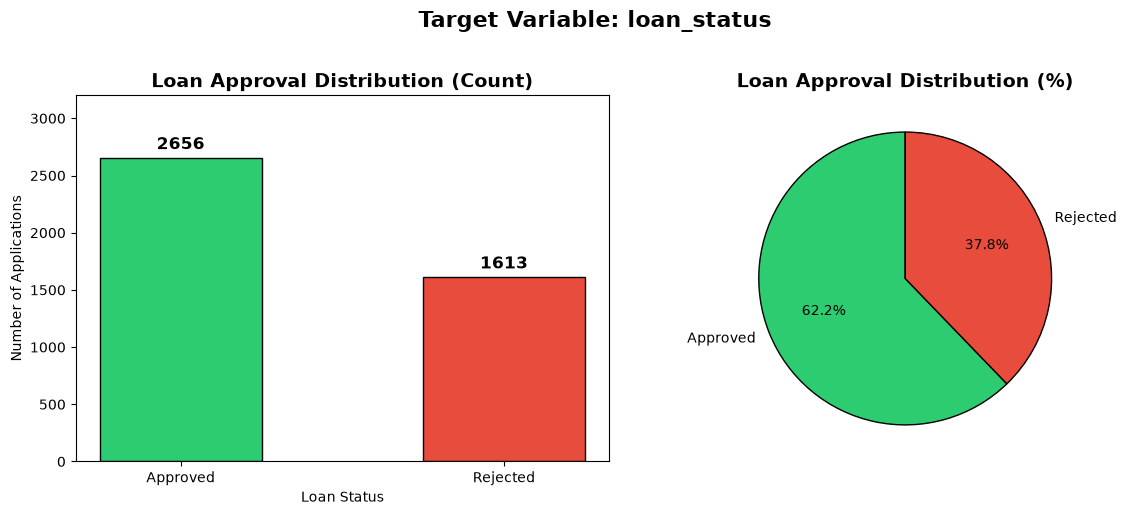

In [19]:
# Count values for the plot
counts = df['loan_status'].value_counts()
labels = counts.index.tolist()       # ['Approved', 'Rejected']
values = counts.values.tolist()      # [2656, 1613]
colors = ['#2ecc71', '#e74c3c']      # green for Approved, red for Rejected

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Bar Chart ---
bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Loan Approval Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Number of Applications')
axes[0].set_ylim(0, 3200)

# Add count labels on top of each bar
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 40,
                 str(val),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- Right: Pie Chart ---
axes[1].pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Loan Approval Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: loan_status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [20]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64

In [21]:
approved = df[df['loan_status'] == 'Approved']['cibil_score']
rejected = df[df['loan_status'] == 'Rejected']['cibil_score']

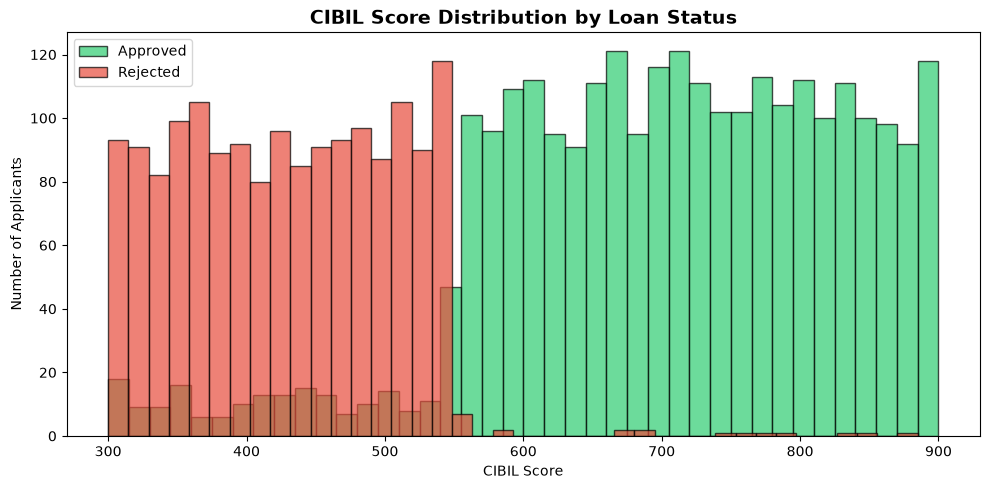

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(approved, bins=40, alpha=0.7, color='#2ecc71', label='Approved', edgecolor='black')
ax.hist(rejected, bins=40, alpha=0.7, color='#e74c3c', label='Rejected', edgecolor='black')

ax.set_title('CIBIL Score Distribution by Loan Status', fontsize=14, fontweight='bold')
ax.set_xlabel('CIBIL Score')
ax.set_ylabel('Number of Applicants')
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
approved_income = df[df['loan_status'] == 'Approved']['income_annum']
rejected_income = df[df['loan_status'] == 'Rejected']['income_annum']

approved_loan = df[df['loan_status'] == 'Approved']['loan_amount']
rejected_loan = df[df['loan_status'] == 'Rejected']['loan_amount']


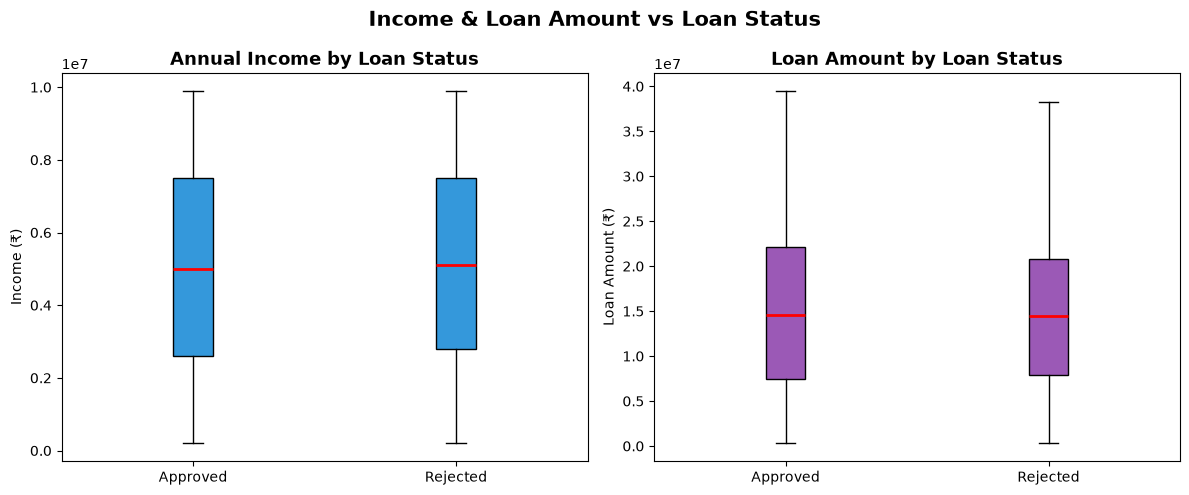

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([approved_income, rejected_income],
                tick_labels=['Approved', 'Rejected'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Annual Income by Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Income (₹)')

axes[1].boxplot([approved_loan, rejected_loan],
                tick_labels=['Approved', 'Rejected'],
                patch_artist=True,
                boxprops=dict(facecolor='#9b59b6', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Loan Amount by Loan Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loan Amount (₹)')

plt.suptitle('Income & Loan Amount vs Loan Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
edu_approved = df[df['loan_status'] == 'Approved']['education'].value_counts()
edu_rejected = df[df['loan_status'] == 'Rejected']['education'].value_counts()

emp_approved = df[df['loan_status'] == 'Approved']['self_employed'].value_counts()
emp_rejected = df[df['loan_status'] == 'Rejected']['self_employed'].value_counts()


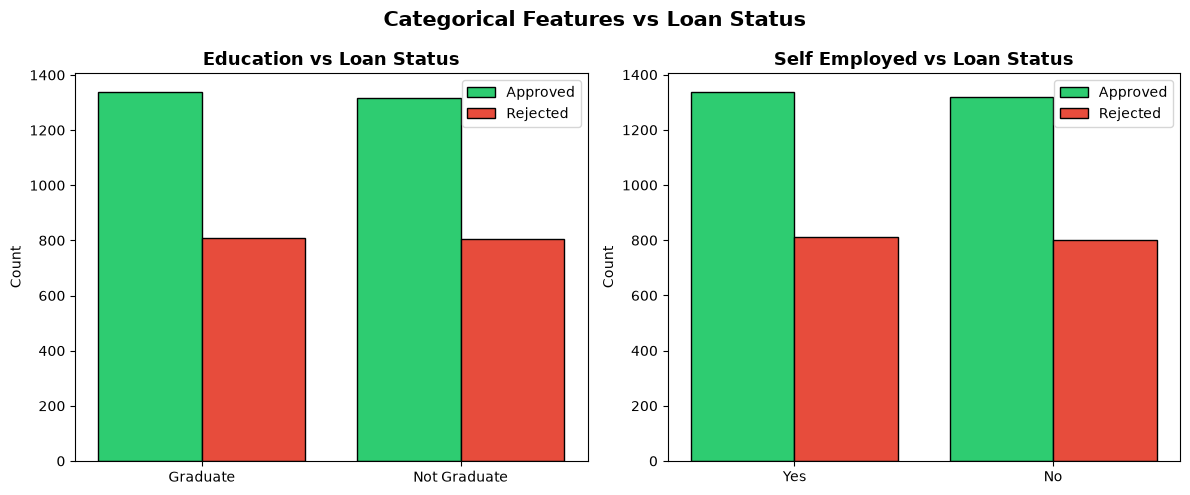

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x1 = np.arange(len(edu_approved))
axes[0].bar(x1 - 0.2, edu_approved.values, width=0.4, label='Approved', color='#2ecc71', edgecolor='black')
axes[0].bar(x1 + 0.2, edu_rejected.values, width=0.4, label='Rejected', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(edu_approved.index)
axes[0].set_title('Education vs Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()

x2 = np.arange(len(emp_approved))
axes[1].bar(x2 - 0.2, emp_approved.values, width=0.4, label='Approved', color='#2ecc71', edgecolor='black')
axes[1].bar(x2 + 0.2, emp_rejected.values, width=0.4, label='Rejected', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(emp_approved.index)
axes[1].set_title('Self Employed vs Loan Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Categorical Features vs Loan Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
asset_cols = ['residential_assets_value', 'commercial_assets_value',
              'luxury_assets_value', 'bank_asset_value']

approved_assets = [df[df['loan_status'] == 'Approved'][col].median() for col in asset_cols]
rejected_assets = [df[df['loan_status'] == 'Rejected'][col].median() for col in asset_cols]

short_labels = ['Residential', 'Commercial', 'Luxury', 'Bank']


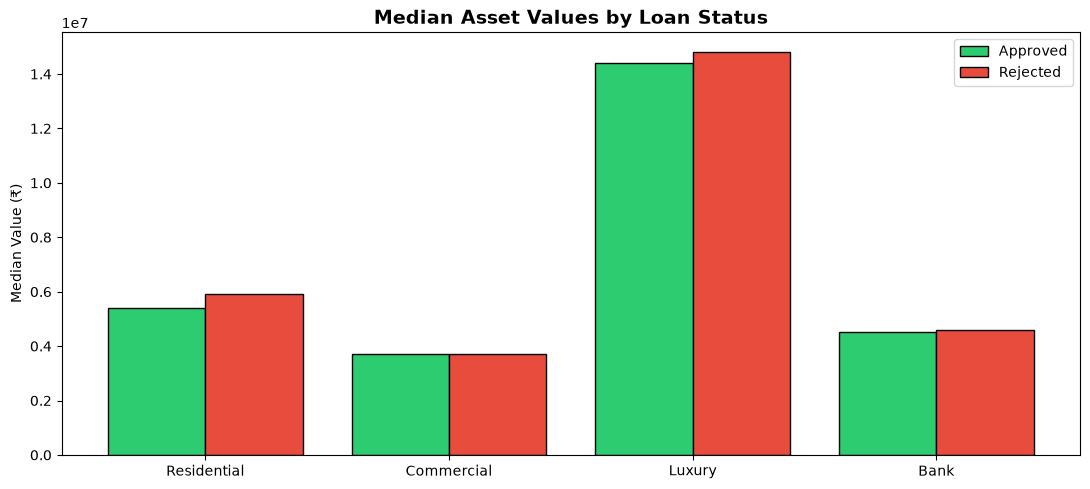

In [28]:
x = np.arange(len(short_labels))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, approved_assets, width=0.4, label='Approved', color='#2ecc71', edgecolor='black')
ax.bar(x + 0.2, rejected_assets, width=0.4, label='Rejected', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(short_labels)
ax.set_title('Median Asset Values by Loan Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Value (₹)')
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   str  
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 487.4 KB


In [30]:
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
    })

In [31]:
df['loan_status'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0})

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(11), str(1)
memory usage: 411.3 KB


In [33]:
df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


In [35]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"\nTraining class split:\n{y_train.value_counts()}")
print(f"\nTest class split:\n{y_test.value_counts()}")


Training samples: 3415
Test samples:     854

Training class split:
loan_status
1    2125
0    1290
Name: count, dtype: int64

Test class split:
loan_status
1    531
0    323
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [39]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First row of X_train before scaling:")
print(X_train.iloc[0].values)
print("\nFirst row of X_train after scaling:")
print(X_train_scaled[0].round(3))


First row of X_train before scaling:
[       4        1        0  4800000 14300000        6      795  5900000
        0 11100000  2600000]

First row of X_train after scaling:
[ 0.891  0.999 -1.009 -0.093 -0.089 -0.851  1.131 -0.235 -1.137 -0.444
 -0.737]


In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [41]:
lr_preds = lr_model.predict(X_test_scaled)
print("Logistic Regression - First 10 predictions:", lr_preds[:10])
print("Actual values:                              ", y_test.values[:10])


Logistic Regression - First 10 predictions: [1 0 1 1 1 1 1 0 1 0]
Actual values:                               [0 0 0 1 1 1 1 0 1 0]


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [43]:
rf_preds = rf_model.predict(X_test)
print("Random Forest - First 10 predictions:", rf_preds[:10])
print("Actual values:                        ", y_test.values[:10])


Random Forest - First 10 predictions: [1 0 0 1 1 1 1 0 1 0]
Actual values:                         [0 0 0 1 1 1 1 0 1 0]


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [45]:
metrics = {
    'Accuracy':  [accuracy_score(y_test, lr_preds),  accuracy_score(y_test, rf_preds)],
    'Precision': [precision_score(y_test, lr_preds), precision_score(y_test, rf_preds)],
    'Recall':    [recall_score(y_test, lr_preds),    recall_score(y_test, rf_preds)],
    'F1 Score':  [f1_score(y_test, lr_preds),        f1_score(y_test, rf_preds)]
}

results_df = pd.DataFrame(metrics, index=['Logistic Regression', 'Random Forest'])
print(results_df.round(4))


                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9133     0.9208  0.9416    0.9311
Random Forest          0.9801     0.9831  0.9849    0.9840


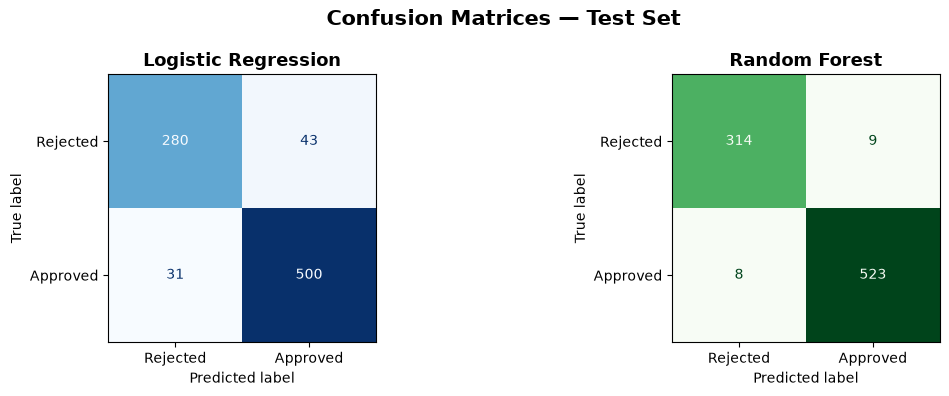

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, lr_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Rejected', 'Approved'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Rejected', 'Approved'])

disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression', fontsize=13, fontweight='bold')

disp_rf.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


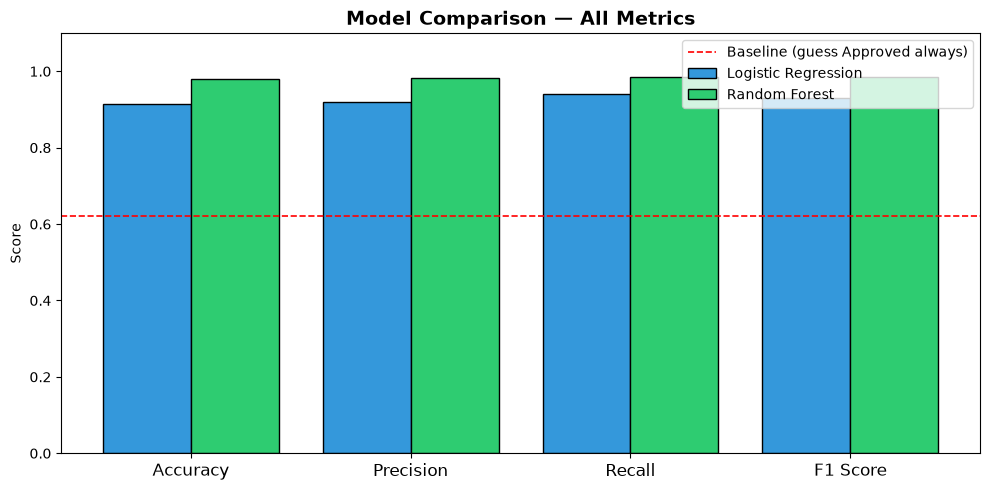

In [47]:
metric_names = list(metrics.keys())
lr_scores = results_df.loc['Logistic Regression'].values
rf_scores = results_df.loc['Random Forest'].values

x = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 0.2, lr_scores, width=0.4, label='Logistic Regression', color='#3498db', edgecolor='black')
ax.bar(x + 0.2, rf_scores, width=0.4, label='Random Forest', color='#2ecc71', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=0.62, color='red', linestyle='--', linewidth=1.2, label='Baseline (guess Approved always)')
ax.legend()

plt.tight_layout()
plt.show()


In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [49]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto

In [50]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score: 0.9845


In [51]:
tuned_preds = grid_search.best_estimator_.predict(X_test)

print("\nTuned Random Forest — Test Set Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Precision: {precision_score(y_test, tuned_preds):.4f}")
print(f"Recall:    {recall_score(y_test, tuned_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, tuned_preds):.4f}")



Tuned Random Forest — Test Set Metrics:
Accuracy:  0.9824
Precision: 0.9831
Recall:    0.9887
F1 Score:  0.9859


In [52]:
import joblib

joblib.dump(grid_search.best_estimator_, 'loan_approval_model.pkl')
print("Model saved successfully!")


Model saved successfully!


In [53]:
loaded_model = joblib.load('loan_approval_model.pkl')

test_prediction = loaded_model.predict(X_test[:5])
print("Predictions from loaded model:", test_prediction)
print("Actual values:                ", y_test.values[:5])


Predictions from loaded model: [1 0 0 1 1]
Actual values:                 [0 0 0 1 1]


In [54]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances)

cibil_score                 0.802381
loan_term                   0.062527
loan_amount                 0.031339
income_annum                0.019897
luxury_assets_value         0.019041
residential_assets_value    0.017823
commercial_assets_value     0.017483
bank_asset_value            0.016031
no_of_dependents            0.008272
education                   0.002607
self_employed               0.002600
dtype: float64


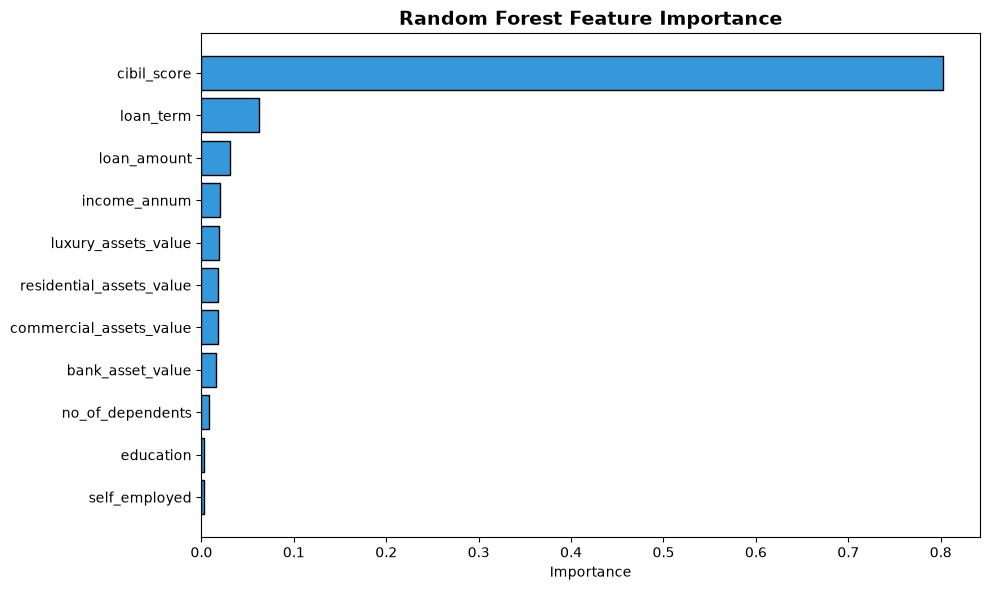

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index[::-1], importances.values[::-1], color='#3498db', edgecolor='black')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [56]:
X_no_cibil = X.drop(columns=['cibil_score'])

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cibil, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
rf_no_cibil = RandomForestClassifier(random_state=42, n_estimators=100)
rf_no_cibil.fit(X_train_nc, y_train_nc)

nc_preds = rf_no_cibil.predict(X_test_nc)

print(f"Accuracy without CIBIL:  {accuracy_score(y_test_nc, nc_preds):.4f}")
print(f"F1 Score without CIBIL:  {f1_score(y_test_nc, nc_preds):.4f}")
print(f"\nFor comparison — WITH CIBIL:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_preds):.4f}")

Accuracy without CIBIL:  0.5972
F1 Score without CIBIL:  0.7143

For comparison — WITH CIBIL:
Accuracy: 0.9801
F1 Score: 0.9840


## Model Interpretation

Feature importance and an ablation test (removing cibil_score entirely) confirm
that cibil_score accounts for ~80% of the model's decision-making. Without it,
accuracy drops from 98% to 59.7% — below the lazy baseline. This model is
effectively a CIBIL-score threshold classifier with minor contributions from
loan_term and loan_amount. Other features (income, assets, education,
employment) have minimal individual predictive power in this dataset.